# TP : Transfert Learning avec VGG16

### Télécharger `dog-and-cat-classification-dataset`

<p style="color: gray">Note : Kaggle est une plateforme communautaire dédiée au data science et au machine learning, hébergeant des milliers de jeux de données publics, des compétitions et des notebooks collaboratifs. Elle permet aux praticiens d'accéder facilement à des corpus annotés, de partager leurs expériences et de progresser collectivement dans l'analyse de données et la construction de modèles prédictifs.</p>

- Télécharger le dataset "dog-and-cat-classification-dataset" depuis Kaggle en utilisant la bibliothèque `kagglehub`.
- Afficher le chemin local où les fichiers du dataset ont été sauvegardés.
- Créer la variable `images_dir` qui contient les sous-dossiers d'images
- Explorer le dossier d’images téléchargé (`PetImages`) et affiche pour chaque sous-dossier (Cat/Dog) le nombre de fichiers qu’il contient.


In [34]:
#!pip install kagglehub

In [35]:
import os
import kagglehub

root_dir = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Path to dataset files:", root_dir)

# Le chemin vers le dossier d'images (nommé "PetImages" dans ce dataset)
images_dir = os.path.join(root_dir, "PetImages")

print(f"Contents of {os.path.basename(images_dir)}")
for item in os.listdir(images_dir):
    item_path = os.path.join(images_dir, item)
    if os.path.isdir(item_path):
        num_files = len(os.listdir(item_path))
        print(f"  {item}/ - {num_files} files")
    else:
        print(f"  {item}")

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset
Contents of PetImages
  Dog/ - 12499 files
  Cat/ - 12499 files


### Préparer l'environnement logiciel

In [36]:
import os
import random
from glob import glob
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import albumentations as A
from tqdm.auto import tqdm

from torchvision import models
from torchsummary import summary
import copy


### Encoder les classes cibles
Implémentez l'encodage des deux étiquettes textuelles du jeu Cats vs Dogs grâce à `sklearn.preprocessing.LabelEncoder` :

- Créez l'instance `LabelEncoder`
- Appelez `fit(['Cat', 'Dog'])` pour apprendre les classes (les indexer)
- Affichez le dictionnaire de correspondance entre noms de classes et entiers
- Fixez ainsi définitivement le codage binaire utilisé ensuite

In [37]:
# Encodage des labels

from sklearn.preprocessing import LabelEncoder

labelEncoder=LabelEncoder()

v=labelEncoder.fit(["Cat","Dog"])


# TODO

### Construire le référentiel des données

- Définir `MAX_SAMPLES_PER_CLASS` pour limiter le nombre d'images par catégorie
- Utiliser `glob` pour récupérer les chemins des fichiers `.jpg` dans le sous-dossier `Cat`
- Utiliser `glob` pour récupérer les chemins des fichiers `.jpg` dans le sous-dossier `Dog`
- Limiter chaque liste à `MAX_SAMPLES_PER_CLASS` échantillons
- Concaténer les deux listes pour obtenir `all_files`
- Créer une liste `all_labels` répétant l'indice de `Cat` pour tous les fichiers de chats, puis l'indice de `Dog` pour tous les fichiers de chiens (utilisez `label_encoder`)
- Construire un `DataFrame` pandas nommé `df` avec les colonnes `file_path` et `label`
- Afficher le nombre total de fichiers avec `len(df)`
- Afficher les premières lignes du `DataFrame` avec `display(df.head())`


In [38]:
MAX_SAMPLES_PER_CLASS = 1000

all_cat=glob(f"{images_dir}/Cat/*.jpg")[:MAX_SAMPLES_PER_CLASS]
all_dog=glob(f"{images_dir}/Dog/*.jpg")[:MAX_SAMPLES_PER_CLASS]

all_files=all_cat
all_files.extend(all_dog)
cats=["Cat" for _ in range(MAX_SAMPLES_PER_CLASS)]
dogs=["Dog" for _ in range(MAX_SAMPLES_PER_CLASS)]
target=cats
target.extend(dogs)

target= labelEncoder.transform(target)


df=pd.DataFrame({"file_path":all_files,"label":target})
# TODO
print("Total files:", len(df))
display(df.head())
print("\nDistribution des labels:")
print(df['label'].value_counts())

Total files: 2000


,file_path,label
0,/kaggle/input/dog-and-cat-classification-datas...,0
1,/kaggle/input/dog-and-cat-classification-datas...,0
2,/kaggle/input/dog-and-cat-classification-datas...,0
3,/kaggle/input/dog-and-cat-classification-datas...,0
4,/kaggle/input/dog-and-cat-classification-datas...,0



Distribution des labels:
label
0    1000
1    1000
Name: count, dtype: int64


### Implémenter la classe `CatsDogsDataset`
Rédigez la classe `CatsDogsDataset(root_dir, dataframe, transform=None)` en précisant :

- **Constructeur (`__init__`)** :
    - Stocke les chemins des images (`root_dir` et `dataframe`).
    - Accepte une transformation optionnelle (`transform`).

- **Méthode `__len__(self)`** :
    - Retourne la taille du corpus, c'est-à-dire le nombre d'images dans le `dataframe`.

- **Méthode `__getitem__(self, idx)`** :
    - Charge l'image à partir du chemin spécifié dans le `dataframe` en utilisant `PIL.Image`.
    - Uniformise l'image en RGB et redimensionne à 128×128 pixels.
    - Applique la transformation si fournie.
    - Renvoie le couple `(image, label)` où `label` est extrait du `dataframe`.


Instanciez `CatsDogsDataset` dans `full_dataset`avec le répertoire racine et le `DataFrame` précédemment construits.

In [39]:
from cv2 import cvtColor
from albucore import cv2
class CatsDogsDataset(Dataset):
    def __init__(self, root_dir, dataframe, transform=None):
      super().__init__()
      self.df=dataframe
      self.root_dir=root_dir
      self.transform=transform

    def __len__(self):
      return len(self.df)

    def __getitem__(self, idx):
      row = self.df.iloc[idx]
      img = Image.open(row['file_path'])
      img = img.resize((128, 128))
      img = img.convert("RGB")
      img = np.array(img)
      if self.transform:
        return self.transform(image=img)['image'],row['label']
      return img,row['label']

full_dataset = CatsDogsDataset(root_dir=images_dir, dataframe=df)
print("Dataset size:", len(full_dataset))

# Afficher un échantillon
sample_img, sample_label = full_dataset[0]
sample_label_str = labelEncoder.inverse_transform([sample_label])[0]
print(f"Sample data image shape: {sample_img.shape}, label: {sample_label} ({sample_label_str})")

Dataset size: 2000
Sample data image shape: (128, 128, 3), label: 0 (Cat)


### Examiner la diversité des données

Créer une figure pour afficher 8 images en 2 lignes de 4 colonnes :
- Boucler pour sélectionner aléatoirement un indice dans `full_dataset` avec `random.randint()`
- Charger l'image et le label correspondants
- Afficher l'image
- Convertir le label numérique en texte
- Définir le titre de chaque image


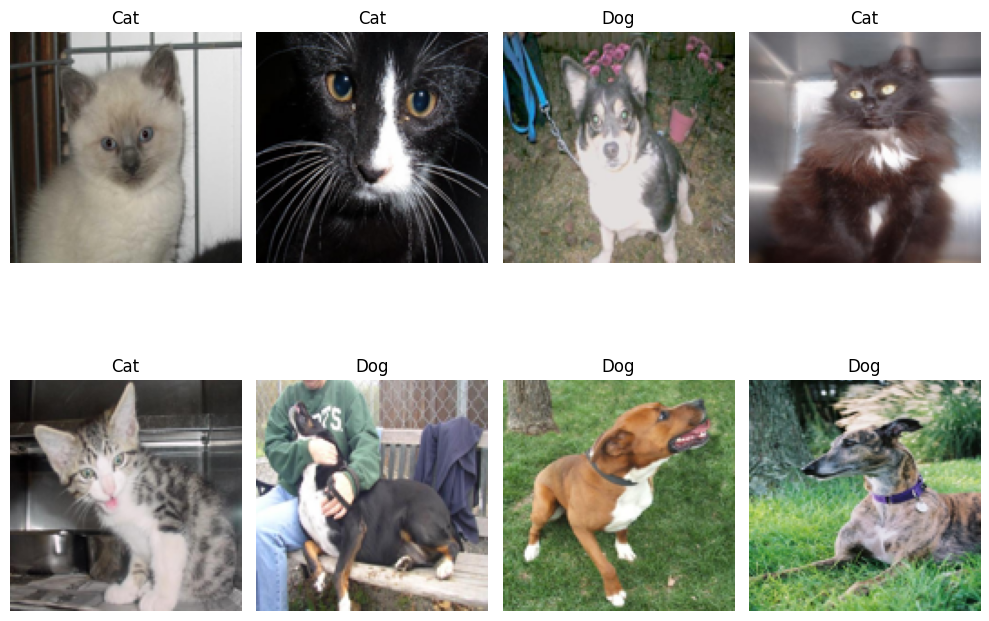

In [40]:

fig,axes=plt.subplots(2,4,figsize=(10,8))

axes=axes.flatten()

for i,axe in enumerate(axes):
  index=random.randint(0,len(full_dataset))
  axe.imshow(full_dataset[index][0])
  axe.set_title(labelEncoder.inverse_transform([full_dataset[index][1]])[0])
  axe.axis('off')
plt.tight_layout()
plt.show()


### Séparer apprentissage, validation et test

Exploitez `train_test_split` de `scikit-learn` pour diviser le `DataFrame` en trois ensembles :
- **Premier split** : séparez `df` en `train_val_df` (80 %) et `test_df` (20 %) avec `test_size=0.2`, `random_state=42` et `stratify=df['label']` pour conserver la proportion des classes.
- **Second split** : divisez `train_val_df` en `train_df` (60 % du total) et `val_df` (20 % du total) avec `test_size=0.25` (car 0.25 × 0.8 = 0.2), `random_state=42` et `stratify=train_val_df['label']`.
- Affichez le nombre d'échantillons dans chaque ensemble avec `len(train_df)`, `len(val_df)` et `len(test_df)` pour vérifier la répartition finale (approximativement 60 % / 20 % / 20 %).


In [41]:
train_val_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df['label'])

train_df,val_df=train_test_split(train_val_df,test_size=0.25,random_state=42,stratify=train_val_df['label'])

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 1200
Validation samples: 400
Test samples: 400


### Configurer les pipelines d'augmentation

(Inspirez-vous du dernier TD)

- Déclarez les tenseurs `MEAN` et `STD` d'ImageNet pour la normalisation des images.
- Construisez le pipeline `train_transforms` avec :
    - Recadrage redimensionné aléatoire (`RandomResizedCrop`)
    - Flip horizontal aléatoire (`HorizontalFlip`)
    - Ajustements de luminosité et contraste (`RandomBrightnessContrast`)
    - Modifications de teinte, saturation et valeur (`HueSaturationValue`)
    - Ajout de bruit ou flou (`GaussNoise`, `GaussianBlur`)
    - Masquage partiel aléatoire (`CoarseDropout`)
    - Normalisation (`Normalize`)
    - Conversion en tenseur PyTorch (`ToTensorV2`)
- Définissez le pipeline `test_transforms` (pour validation/test) avec :
    - Redimensionnement à IMG_SIZExIMG_SIZE pixels (`Resize`)
    - Normalisation (`Normalize`)
    - Conversion en tenseur (`ToTensorV2`)


In [42]:
# Définition des transformations avec Albumentations


IMG_SIZE = 128
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transforms = A.Compose([
    A.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3),
    A.OneOf([
        A.GaussNoise(std_range=(0.1, 0.2), p=1.0),
        A.GaussianBlur(sigma_limit=(0.5, 3), p=1.0),
    ], p=0.2),
    A.CoarseDropout(num_holes_range=(1,8),
                    hole_height_range=(int(IMG_SIZE * 0.0625),int(IMG_SIZE * 0.125)),
                    hole_width_range=(int(IMG_SIZE * 0.0625),int(IMG_SIZE * 0.125)), p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    A.ToTensorV2()
])

test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    A.ToTensorV2()
])



### Préparer les DataLoaders

- Définir `BATCH_SIZE` (par exemple 32)
- Créer `train_dataset` avec `train_df` et `train_transforms`
- Créer `val_dataset` avec `val_df` et `test_transforms`
- Créer `test_dataset` avec `test_df` et `test_transforms`
- Créer `train_loader` avec `shuffle=True`
- Créer `val_loader` avec `shuffle=False`
- Créer `test_loader` avec `shuffle=False`
- Afficher le nombre de batches pour chaque DataLoader


In [43]:
BATCH_SIZE = 32

train_dataset=CatsDogsDataset(root_dir=images_dir,dataframe=train_df,transform=train_transforms)
test_dataset=CatsDogsDataset(root_dir=images_dir,dataframe=test_df,transform=test_transforms)
val_dataset=CatsDogsDataset(root_dir=images_dir,dataframe=val_df,transform=test_transforms)

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_dataset,shuffle=False,batch_size=BATCH_SIZE)
val_loader=DataLoader(val_dataset,shuffle=False,batch_size=BATCH_SIZE)

# TODO

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Train loader batches: 38
Validation loader batches: 13
Test loader batches: 13


### Visualiser les effets de l'augmentation de données

Générez et affichez 10 exemples d'images augmentées issues du dataset d'entraînement pour observer concrètement l'impact des transformations appliquées.

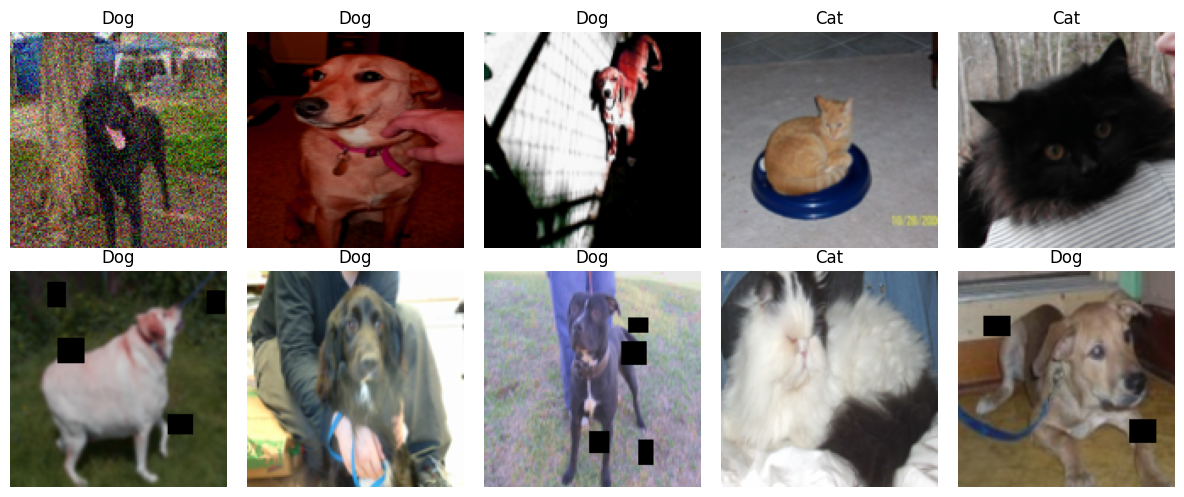

In [44]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
# axes = axes.ravel()
for axe in axes.flatten():
    idx = random.randint(0, len(train_dataset) - 1)
    img, label = train_dataset[idx]
    img = img.permute(1, 2, 0).numpy()  # Convertir de CxHxW à HxWxC
    img = (img * STD) + MEAN  # Dénormaliser
    img = np.clip(img, 0, 1)  # S'assurer que les valeurs sont entre 0 et 1
    axe.imshow(img)
    axe.set_title(f"{labelEncoder.inverse_transform([label])[0]}")
    axe.axis('off')
plt.tight_layout()
plt.show()

### Sélectionner le dispositif de calcul qu'on va utiliser

- Détecter l’accélérateur disponible dans l’ordre de priorité: `CUDA` → `MPS` (Mac Apple Silicon) → `CPU` et le stocker dans `device`.
- Afficher le device retenu: `print("Using device:", device)`.


In [45]:
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu'
print("Using device:", device)

Using device: cuda


### Charger le backbone VGG16 pré-entraîné

Implémentez le chargement du modèle VGG16 pré-entraîné en suivant ces étapes :

- Utilisez `torchvision.models.vgg16` pour charger l'architecture VGG16
- Spécifiez `weights='IMAGENET1K_V1'` pour charger les poids pré-entraînés sur ImageNet
- Stockez le modèle dans la variable `model`
- Cette base convolutive riche servira de point de départ pour l'adaptation à la tâche de classification binaire Cats vs Dogs

In [46]:
model = models.vgg16(weights='IMAGENET1K_V1')

### Examiner l'architecture initiale

- Utiliser `torchsummary.summary` pour inspecter la structure actuelle de VGG16
- Admirez la succession des blocs convolutifs et le volume des paramètres avant toute modification

In [47]:
model.to(device)
summary(model, input_size=(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

### Geler les poids de la base convolutive

Avant d'adapter le modèle VGG16 à notre tâche de classification binaire, il est essentiel de figer les poids pré-entraînés du backbone convolutif pour conserver les représentations visuelles apprises sur ImageNet. Voici les étapes à suivre :

- Parcourez tous les paramètres du modèle avec `model.parameters()`
- Pour chaque paramètre, désactivez le calcul des gradients en positionnant `param.requires_grad = False`
- Cette opération garantit que seules les couches du classifieur ajoutées ultérieurement seront optimisées lors de l'entraînement : les poids convolutifs pré-entraînés resteront ainsi figés et serviront d'extracteur de caractéristiques fixes

In [48]:
for param in model.parameters():
  param.requires_grad=False

### Vérifier l'absence de paramètres entraînables

Après avoir gelé les poids de la base convolutive VGG16, on vérifie que l'opération a bien été effectuée :

- Utiliser `torchsummary.summary` avec les mêmes dimensions d'entrée que précédemment
- Observer que le nombre de paramètres entraînables (trainable params) doit être à 0
- Vérifier que tous les paramètres du backbone convolutif sont désormais marqués comme non-entraînables
- Cette vérification atteste que seules les nouvelles couches ajoutées ultérieurement au classifieur seront optimisées lors de l'entraînement

In [49]:
summary(model,input_size=(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

### Contrôler la structure courante du modèle

Affichez simplement l'objet `model` pour obtenir une représentation textuelle détaillée de la hiérarchie des sous-modules, ce qui facilitera l'identification des couches à personnaliser.

In [50]:
display(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Adapter la tête de classification

Pour adapter le modèle VGG16 pré-entraîné à la tâche de classification binaire, il faut modifier les dernières couches du réseau :

- **Réduire la sortie de l'avgpool** : redéfinir `model.avgpool` avec nn.AdaptiveAvgPool2d((1, 1))` pour obtenir une sortie spatiale de 1×1, ce qui produit un vecteur de 512 caractéristiques par image au lieu de 25088 (7×7×512)

- **Remplacer le classifieur** : redéfinir `model.classifier` comme une séquence `nn.Sequential` comprenant :
    - `nn.Flatten()` : aplatit le tenseur en vecteur unidimensionnel
    - `nn.Linear(512, 128)` : couche dense réduisant de 512 à 128 neurones
    - `nn.ReLU()` : fonction d'activation non-linéaire
    - `nn.Dropout(0.2)` : régularisation pour prévenir le surapprentissage (20% des neurones désactivés)
    - `nn.Linear(128, 1)` : couche de sortie à 1 neurone pour la classification binaire
    - `nn.Sigmoid()` : fonction d'activation produisant une probabilité entre 0 et 1

- **Résultat** : Le nouveau classifieur est adapté à notre tâche binaire, tandis que la base convolutive VGG16 gelée sert d'extracteur de caractéristiques pré-entraîné

In [51]:
model.avgpool = nn.AdaptiveAvgPool2d((1,1))
model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512,128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128,1),
    nn.Sigmoid()
)

### Visualiser le modèle ajusté

In [52]:
display(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Valider les dimensions d'inférence

Vérifier que le modèle modifié traite correctement les données en suivant le flux de transformations dimensionnelles :

- Utiliser `torch.no_grad()` pour désactiver le calcul des gradients lors de cette validation
- Créer un tenseur factice simulant un lot d'images
- Passer ce tenseur à travers `model.features` (backbone convolutif VGG16) et afficher la forme de sortie
- Appliquer `model.avgpool` vérifier la réduction dimensionnelle
- Propager le résultat dans `model.classifier` et confirmer la forme finale `(BATCH_SIZE, 1)`

In [53]:
input=torch.from_numpy(np.array([torch.rand((3,128,128),dtype=torch.float) for _ in range(BATCH_SIZE)])).to(device)
model.to(device)
with torch.no_grad():
  conv_output=model.features(input)
  print(conv_output.shape)
  avg_pool_output=model.avgpool(conv_output)
  print(avg_pool_output.shape)
  output=model.classifier(avg_pool_output)
  print(output.shape)
    # TODO


torch.Size([32, 512, 4, 4])
torch.Size([32, 512, 1, 1])
torch.Size([32, 1])


### Confirmer le nombre de paramètres après adaptation
Relancez `torchsummary.summary` sur le modèle modifié pour confirmer que seules les couches récemment ajoutées demeurent entraînables et pour quantifier le nombre total de paramètres mis à jour.

In [54]:
summary(model,input_size=(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           1,792
              ReLU-2         [-1, 64, 128, 128]               0
            Conv2d-3         [-1, 64, 128, 128]          36,928
              ReLU-4         [-1, 64, 128, 128]               0
         MaxPool2d-5           [-1, 64, 64, 64]               0
            Conv2d-6          [-1, 128, 64, 64]          73,856
              ReLU-7          [-1, 128, 64, 64]               0
            Conv2d-8          [-1, 128, 64, 64]         147,584
              ReLU-9          [-1, 128, 64, 64]               0
        MaxPool2d-10          [-1, 128, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]         295,168
             ReLU-12          [-1, 256, 32, 32]               0
           Conv2d-13          [-1, 256, 32, 32]         590,080
             ReLU-14          [-1, 256,

### Coder la boucle d'entraînement élémentaire
Définissez la fonction `train_batch(model, x, y, loss_fn, optimizer)` qui effectue les opérations suivantes :

- Placer le modèle en mode entraînement
- Effectuer la passe avant en calculant les prédictions
- Calculer la perte
- Rétropropager les gradients
- Mettre à jour les poids
- Réinitialiser les gradients
- Renvoyer la valeur numérique de la perte

In [55]:
def train_batch(model, x, y, loss_fn, optimizer):
  """
  Effectue une étape d'entraînement sur un batch.

  Args:
      model (torch.nn.Module): Le modèle à entraîner.
      x (torch.Tensor): Les entrées du batch (images).
      y (torch.Tensor): Les labels du batch.
      loss_fn (callable): La fonction de perte à utiliser.
      optimizer (torch.optim.Optimizer): L'optimiseur pour la mise à jour des poids.

  Returns:
      float: La valeur de la perte pour ce batch.
  """
  model.train()
  predictions = model(x)
  batch_loss = loss_fn(predictions, y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()



### Mesurer la précision binaire par lot
Implémentez la fonction `accuracy(model, x, y)` :
- Décorez la fonction avec `@torch.no_grad()` pour désactiver le calcul des gradients.
- Placez le modèle en mode évaluation avec `model.eval()`.
- Passez les entrées `x` dans le modèle pour obtenir les probabilités.
- Appliquez un seuil à 0,5 pour convertir les probabilités en prédictions binaires.
- Comparez les prédictions binaires aux labels réels `y`.
- Calculez et retournez la proportion de bonnes classifications (accuracy).

In [56]:
@torch.no_grad()
def accuracy(model, x, y):
  """
  Calcule l'accuracy du modèle sur un batch.

  Args:
      model (torch.nn.Module): Le modèle à évaluer.
      x (torch.Tensor): Les entrées du batch (images).
      y (torch.Tensor): Les labels du batch.

  Returns:
      float: L'accuracy du modèle sur ce batch.
  """
  model.eval()
  predictions = model(x)
  predicted_labels = (predictions >= 0.5).float()
  correct = (predicted_labels == y).sum().item()
  return correct / y.size(0)

### Évaluer le modèle sur un DataLoader complet

Implémentez `evaluate(model, data_loader, loss_fn)`.

In [57]:
# Définition de la fonction d'évaluation sur un DataLoader complet

def evaluate(model, data_loader, loss_fn):
    """
    Évalue le modèle sur l'ensemble fourni par data_loader.

    Args:
        model (torch.nn.Module): Modèle à évaluer.
        data_loader (torch.utils.data.DataLoader): Itérateur de lots (x, y).
        loss_fn (Callable): Fonction de perte binaire (ex. nn.BCELoss).

    Returns:
        Tuple[float, float]: (perte moyenne, accuracy moyenne) sur l'ensemble.
    """
    model.eval()
    total_loss = 0.0
    total_accuracy = 0.0
    total_samples = 0

    for x_batch, y_batch in tqdm(data_loader, desc="Evaluating"):
        x_batch = x_batch.to(device)
        y_batch = y_batch.float().unsqueeze(1).to(device)

        predictions = model(x_batch)
        batch_loss = loss_fn(predictions, y_batch)
        batch_accuracy = accuracy(model, x_batch, y_batch)

        batch_size = x_batch.size(0)
        total_loss += batch_loss.item() * batch_size
        total_accuracy += batch_accuracy * batch_size
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_accuracy = total_accuracy / total_samples
    return avg_loss, avg_accuracy

### Entraîner avec suivi de validation et early stopping
- Instancier la perte et l’optimiseur.
- Déplacer le modèle sur le bon périphérique.
- Fixer le nombre maximal d’époques.
- Initialiser les listes de suivi: `train_losses`, `train_accuracies`, `val_losses`, `val_accuracies`.

- Mettre en place l’early stopping:

    <p style="color: gray">Early stopping est une stratégie de régularisation qui surveille la performance sur un ensemble de validation pendant l’entraînement. Quand la métrique suivie (ici la perte de validation) cesse de s’améliorer de manière significative pendant un nombre consécutif d’époques (patience), on interrompt l’entraînement avant que le modèle ne surapprenne (overfitting). On conserve alors les poids correspondant à la meilleure performance observée afin d’obtenir un modèle plus généralizable.</p>

    - Sauvegarder les meilleurs poids: `best_model_wts = copy.deepcopy(model.state_dict())`.
    NB : au départ ce sont les poids aléatoires.

    - Initialiser les variables:
        - `best_val_loss = inf`,
        - `best_epoch = -1`,
        - `min_delta = 1e-4`,
        - `patience = 3`,
        - `epochs_no_improve = 0`.
    
    - A la fin de chaque époque :
        - Si `avg_val_loss` a diminué de plus de `min_delta`:
            - Mettre à jour `best_val_loss`, `best_epoch`, `best_model_wts`

            - Réinitialiser `epochs_no_improve = 0`.

        - Sinon, incrémenter `epochs_no_improve`

        - Si `epochs_no_improve >= patience`, arrêter l’entraînement (early stopping).

    - Après l’arrêt, restaurer les meilleurs poids grâce à `load_state_dict(best_model_wts)`.


**NB : ETUDIEZ LA SORTIE DE CELLULE QUI VOUS EST FOURNIE !!!**

In [58]:
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model = model.to(device)

n_epochs = 20 # nombre maximal d'époques

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [59]:
# Pour early stopping
best_model_wts = copy.deepcopy(model.state_dict()) # initialisation des meilleurs poids
best_val_loss = float('inf') # initialisation de la meilleure perte de validation
best_epoch = -1 # initialisation de la meilleure époque
min_delta = 1e-4 # amélioration minimale pour considérer que la performance s'est améliorée
patience = 3 # nombre d'époques sans amélioration avant d'arrêter
epochs_no_improve = 0 # compteur d'époques sans amélioration


for epoch in range(n_epochs):
    print(f"Epoch {epoch+1}/{n_epochs}")
    batch_losses = []
    batch_accuracies = []
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc="Train", leave=False)
    for batch_idx, (x_batch, y_batch) in loop:
        x_batch = x_batch.to(device)
        y_batch = y_batch.unsqueeze(-1).float().to(device)
        loss = train_batch(model, x_batch, y_batch, loss_fn, optimizer)
        batch_losses.append(loss)
        acc = accuracy(model, x_batch, y_batch)
        batch_accuracies.append(acc)
        loop.set_postfix(loss=f"{loss:.4f}", acc=f"{acc:.4f}")

    avg_loss = sum(batch_losses) / len(batch_losses)
    avg_acc = sum(batch_accuracies) / len(batch_accuracies)
    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)

    avg_val_loss, avg_val_acc = evaluate(model, val_loader, loss_fn)
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    print(f"Train Loss: {avg_loss:.4f}, Train Accuracy: {avg_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}")

    # Early stopping check (monitor validation loss)
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"Validation loss improved. Saving model weights (epoch {best_epoch}).")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{patience} epochs.")
        if epochs_no_improve >= patience:
            print("Early stopping triggered. Restoring best model weights.")
            break

    print("-" * 30)

# Restore best weights after training (if any improvement occurred)
if best_epoch != -1:
    model.load_state_dict(best_model_wts)
    print(f"Loaded best model from epoch {best_epoch} with val loss {best_val_loss:.4f}")


Epoch 1/20


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.2933, Train Accuracy: 0.9202
Val Loss: 0.1346, Val Accuracy: 0.9500
Validation loss improved. Saving model weights (epoch 1).
------------------------------
Epoch 2/20


Train:   0%|          | 0/38 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1429, Train Accuracy: 0.9367
Val Loss: 0.1116, Val Accuracy: 0.9700
No improvement for 2/3 epochs.
------------------------------
Epoch 6/20


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1385, Train Accuracy: 0.9449
Val Loss: 0.1043, Val Accuracy: 0.9600
No improvement for 3/3 epochs.
Early stopping triggered. Restoring best model weights.
Loaded best model from epoch 3 with val loss 0.1019


In [61]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Visualiser l'évolution des performances

REMARQUE : on a utilisé ici un modèle completement "custom" sur un dataset tronqué, ce qui n'est pas optimal...

Tracez sur deux sous-graphiques l'évolution des pertes et des exactitudes pour l'entraînement et la validation en fonction des époques, légendez correctement les axes et appliquez `plt.tight_layout()` pour assurer une présentation lisible.

- Utilisez les listes `train_losses`, `val_losses`, `train_accuracies`, `val_accuracies` pour afficher les courbes d'apprentissage.
- Placez la perte (loss) sur le premier sous-graphe et l'exactitude (accuracy) sur le second.
- Ajoutez une légende, des titres et des labels d'axes pour chaque sous-figure.
- Utilisez `plt.tight_layout()` pour éviter le chevauchement des éléments graphiques.



6 6


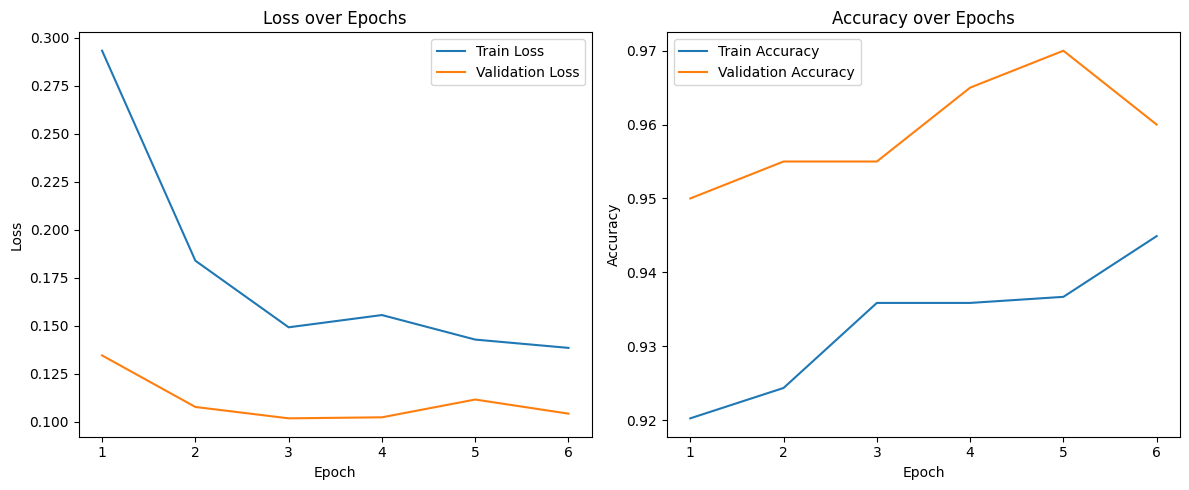

In [62]:
epochs = range(1, len(train_losses) + 1)

print(len(epochs),len(train_losses))

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(range(1, len(train_losses)+1, 1))
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(range(1, len(train_accuracies)+1, 1))
plt.legend()

plt.tight_layout()
plt.show()

### Définir le chemin de sauvegarde du modèle

Indiquez le nom de fichier qui servira à stocker les poids appris du réseau, de sorte à pouvoir réutiliser l'état entraîné ultérieurement.


In [65]:
model_weighths_dir = "/content/drive/MyDrive/computer_vision/model_weights/" # mettez le votre
model_name = "07_transfer_learning_VGG.pth"
weights_path = os.path.join(model_weighths_dir, model_name)

### Sauvegarder les poids du modèle entraîné

Préparez l'appel à `torch.save(model.state_dict(), weights_path)` assorti d'un message de confirmation afin de sérialiser les paramètres du modèle ; laissez ces instructions commentées si vous souhaitez éviter l'écriture automatique lors des tests.


In [66]:
torch.save(model.state_dict(), weights_path)
print(f"Model weights saved to {weights_path}")

Model weights saved to /content/drive/MyDrive/computer_vision/model_weights/07_transfer_learning_VGG.pth


### Recharger un modèle sauvegardé

Chargez les poids depuis `filename` en tenant compte du `device`, appliquez-les au modèle puis affichez un message confirmant que l'état entraîné est correctement restauré.


In [67]:
# TODO
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
print(f"Model weights loaded from {weights_path}")

Model weights loaded from /content/drive/MyDrive/computer_vision/model_weights/07_transfer_learning_VGG.pth


### Afficher la matrice de confusion et le rapport de classification sur le test

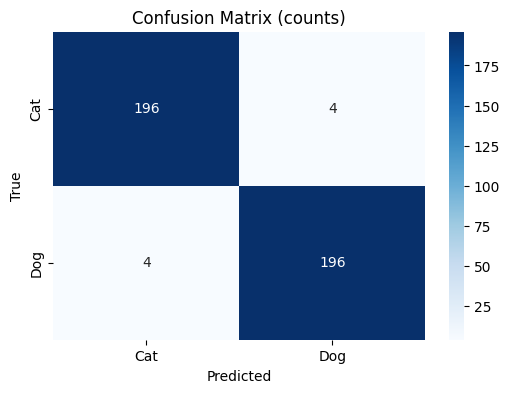


Classification Report:
              precision    recall  f1-score   support

         Cat     0.9800    0.9800    0.9800       200
         Dog     0.9800    0.9800    0.9800       200

    accuracy                         0.9800       400
   macro avg     0.9800    0.9800    0.9800       400
weighted avg     0.9800    0.9800    0.9800       400


Accuracy (sklearn): 0.9800


In [69]:
# TODO
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        labels = y_batch.cpu().numpy().flatten()
        probs = model(x_batch).cpu().numpy().flatten()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.tolist())

all_probs = np.array(all_probs, dtype=float)
all_preds = (all_probs >= 0.5).astype(int)
all_labels = np.array(all_labels, dtype=int)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labelEncoder.classes_, yticklabels=labelEncoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (counts)')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=labelEncoder.classes_, digits=4))

print(f"\nAccuracy (sklearn): {accuracy_score(all_labels, all_preds):.4f}")


### Approfondir par des expérimentations libres
Vous pouvez explorer des variantes d'architecture (ex. Resnet, inception, MobileNet, ...)